# **Medical Cost Personal Dataset**

Medical expenses are any costs incurred in the prevention or treatment of injury or disease. Medical expenses include health and dental insurance premiums, doctor and hospital visits, co-pays, prescription and over-the-counter drugs, glasses and contacts, crutches, and wheelchairs, to name a few. Medical expenses that are not reimbursed are deductible within certain limits.

Link to the dataset : [Click Here](https://www.kaggle.com/mirichoi0218/insurance)

**Columns** :

age: age of primary beneficiary

sex: insurance contractor gender, female, male

bmi: Body mass index, providing an understanding of body, weights that are relatively high or low relative to height,
objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9

children: Number of children covered by health insurance / Number of dependents

smoker: Smoking

region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.

charges: Individual medical costs billed by health insurance

## Importation des librairies

Chargement des bibliothèques Python nécessaires à l'analyse :
- **NumPy / Pandas** — manipulation des données
- **Matplotlib / Seaborn** — visualisations statistiques
- **Statsmodels** — régression OLS avec résumé statistique détaillé


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import statsmodels.api as sm


## Chargement et préparation des données

Lecture du fichier CSV `insurance.csv`. Une copie brute `df_raw` est conservée avec les labels texte originaux pour les visualisations. Les variables catégorielles binaires sont encodées numériquement : `smoker` (yes/no → 1/0) et `sex` (female/male → 1/0).


In [2]:
# Résolution du chemin vers le CSV (fonctionne depuis racine ou notebooks/)
PROJECT_ROOT = os.path.abspath(
    os.path.join(os.getcwd(), '..' if os.path.basename(os.getcwd()) == 'notebooks' else '.')
)
CSV_PATH = os.path.join(PROJECT_ROOT, 'data', 'small_data', 'insurance.csv')

df = pd.read_csv(CSV_PATH)

df_raw = df.copy()

df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].map({'female': 1, 'male': 0})


## Aperçu du dataset

Affichage des 5 premières lignes pour vérifier la structure des colonnes, les types de données et les valeurs après encodage.


In [3]:
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


## Vérification de l'intégrité du dataset

Contrôle que le dataset contient exactement **1 338 lignes × 7 colonnes** sans valeur manquante. Une assertion bloquante est levée si la forme est inattendue.


In [4]:
print(f'Shape : {df.shape}')
print(f'Lignes : {df.shape[0]}, Colonnes : {df.shape[1]}')
assert df.shape == (1338, 7), f'Shape inattendu : {df.shape}'
print('✅ Dataset OK : 1 338 lignes, 7 colonnes, 0 valeur nulle')


Shape : (1338, 7)
Lignes : 1338, Colonnes : 7
✅ Dataset OK : 1 338 lignes, 7 colonnes, 0 valeur nulle


## Types de données par colonne

Affichage du type de chaque colonne (`dtype`) et du nombre de valeurs non-nulles. Permet de détecter des colonnes mal typées ou des valeurs manquantes.


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 73.3+ KB


## Vérification des valeurs manquantes

`isnull().count()` retourne le nombre total de valeurs (nulles ou non) par colonne. Aucune valeur manquante n'est présente dans ce dataset.


In [6]:
df.isnull().count()


age         1338
sex         1338
bmi         1338
children    1338
smoker      1338
region      1338
charges     1338
dtype: int64

## Vérification des types après encodage

Deuxième appel à `df.info()` pour confirmer que `smoker` et `sex` sont bien passés en `int64` suite à l'encodage binaire.


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 73.3+ KB


## Vérification des types après encodage

Deuxième appel à `df.info()` après l'encodage de `smoker` et `sex` pour confirmer que ces colonnes sont bien en `int64` et non `object`.


## Statistiques descriptives

`describe()` retourne pour chaque variable numérique : moyenne, écart-type, minimum, maximum et les quartiles (25%, 50%, 75%). Utile pour détecter les valeurs aberrantes et comprendre l'échelle de chaque variable.


In [8]:
df.describe()


,age,sex,bmi,children,smoker,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.494768,30.663397,1.094918,0.204783,13270.422265
std,14.049960,0.500160,6.098187,1.205493,0.403694,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,4740.287150
50%,39.000000,0.000000,30.400000,1.000000,0.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,16639.912515
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010


---
## 📊 Visualisations — Analyse exploratoire
*Toutes les visualisations utilisent les labels originaux (df_raw) pour la lisibilité.*

### 1. Distribution des charges médicales
La distribution est fortement **asymétrique à droite** (skew positif). On observe deux populations distinctes : les non-fumeurs (charges basses) et les fumeurs (charges élevées). La médiane (~9 382 USD) est bien inférieure à la moyenne (~13 270 USD), confirmant l'effet des valeurs extrêmes.

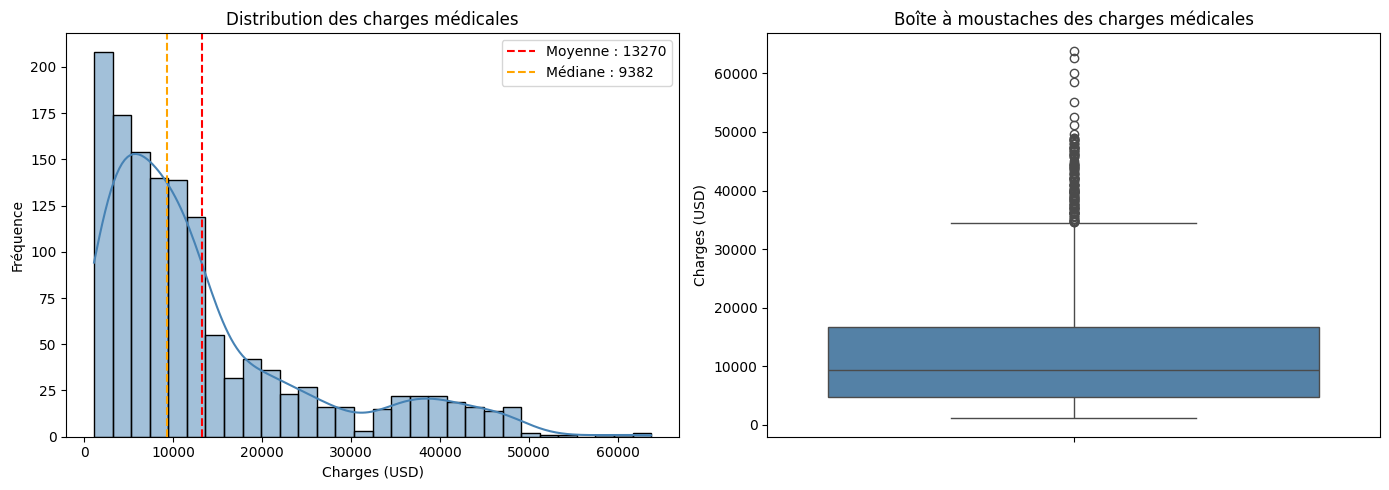

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sb.histplot(df_raw['charges'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution des charges médicales')
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(df_raw['charges'].mean(), color='red', linestyle='--', label=f"Moyenne : {df_raw['charges'].mean():.0f}")
axes[0].axvline(df_raw['charges'].median(), color='orange', linestyle='--', label=f"Médiane : {df_raw['charges'].median():.0f}")
axes[0].legend()
sb.boxplot(y=df_raw['charges'], ax=axes[1], color='steelblue')
axes[1].set_title('Boîte à moustaches des charges médicales')
axes[1].set_ylabel('Charges (USD)')
plt.tight_layout()
plt.show()


### 2. Charges médicales selon le statut fumeur
Les **fumeurs** ont une médiane de charges environ **3× supérieure** aux non-fumeurs. C'est la variable la plus discriminante du dataset (corrélation ~0.79 avec charges). La décision de souscription doit fortement pondérer ce facteur.

/var/folders/sd/_747tl1942g3lfv8k11wjtxc0000gn/T/ipykernel_10063/3091550566.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x='smoker', y='charges', data=df_raw, palette='Set2', ax=axes[0])
/var/folders/sd/_747tl1942g3lfv8k11wjtxc0000gn/T/ipykernel_10063/3091550566.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-fumeur', 'Fumeur'])
/var/folders/sd/_747tl1942g3lfv8k11wjtxc0000gn/T/ipykernel_10063/3091550566.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(x='smoker', y='charges', data=df_raw, palette='Set2', ax=axes[1], inner='quartile')
/var/folders/sd/_747tl1942g3l

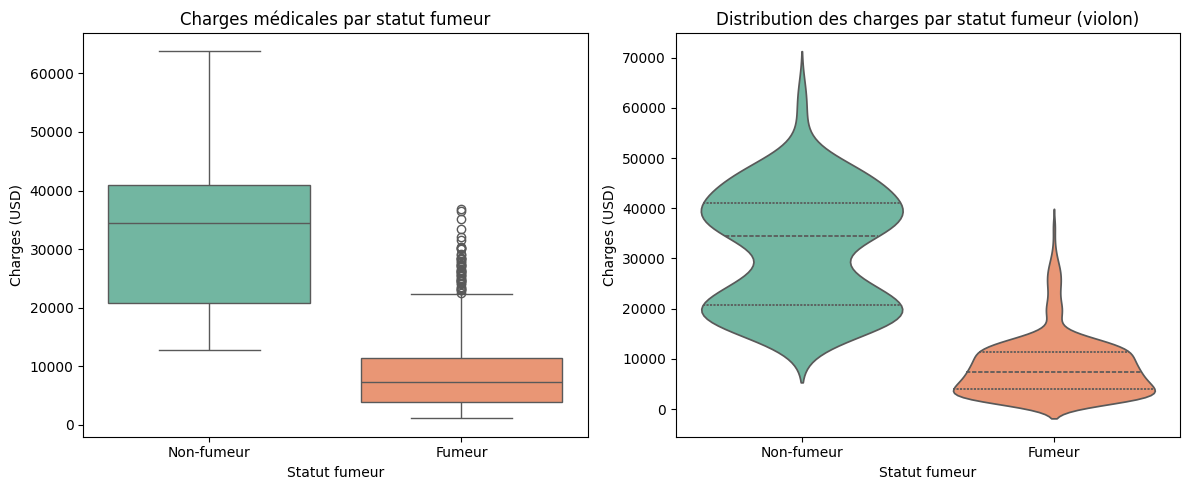

Médiane fumeurs : 34456.348450000005
Médiane non-fumeurs : 7345.4053


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sb.boxplot(x='smoker', y='charges', data=df_raw, palette='Set2', ax=axes[0])
axes[0].set_title('Charges médicales par statut fumeur')
axes[0].set_xlabel('Statut fumeur')
axes[0].set_ylabel('Charges (USD)')
axes[0].set_xticklabels(['Non-fumeur', 'Fumeur'])
sb.violinplot(x='smoker', y='charges', data=df_raw, palette='Set2', ax=axes[1], inner='quartile')
axes[1].set_title('Distribution des charges par statut fumeur (violon)')
axes[1].set_xlabel('Statut fumeur')
axes[1].set_ylabel('Charges (USD)')
axes[1].set_xticklabels(['Non-fumeur', 'Fumeur'])
plt.tight_layout()
plt.show()
print('Médiane fumeurs :', df_raw[df_raw.smoker=='yes']['charges'].median())
print('Médiane non-fumeurs :', df_raw[df_raw.smoker=='no']['charges'].median())


### 3. Charges médicales par région
Les distributions régionales sont **relativement proches**. Le Southeast a des charges légèrement plus élevées (taux d'obésité plus fort). La région seule n'est pas un facteur discriminant majeur pour la souscription.

/var/folders/sd/_747tl1942g3lfv8k11wjtxc0000gn/T/ipykernel_10063/1979005467.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x='region', y='charges', data=df_raw,


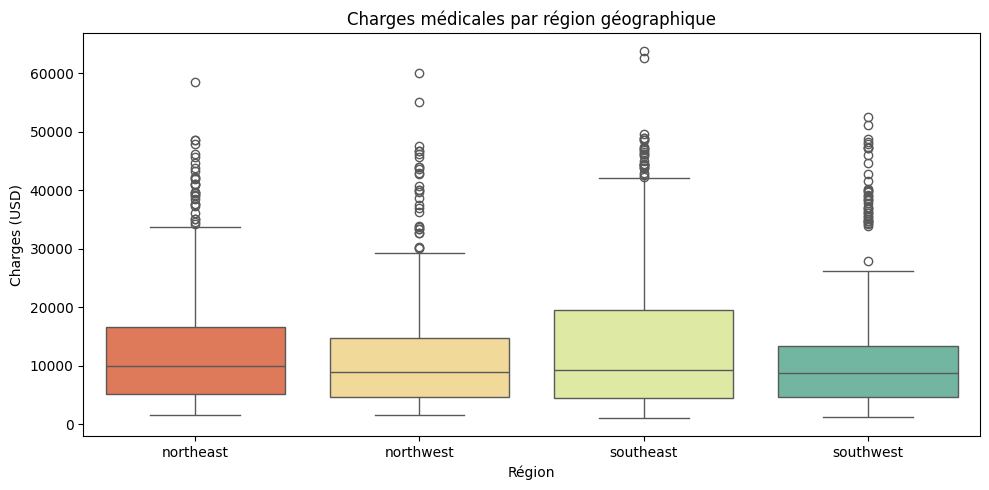

region
northeast    10057.652025
southeast     9294.131950
northwest     8965.795750
southwest     8798.593000
Name: charges, dtype: float64


In [11]:
plt.figure(figsize=(10, 5))
sb.boxplot(x='region', y='charges', data=df_raw,
           order=['northeast','northwest','southeast','southwest'],
           palette='Spectral')
plt.title('Charges médicales par région géographique')
plt.xlabel('Région')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()
print(df_raw.groupby('region')['charges'].median().sort_values(ascending=False))


### 4. Charges médicales par sexe
La différence de charges entre hommes et femmes est **faible et peu significative** (p-valeur OLS > 0.05). Le sexe ne sera pas un facteur déterminant dans le modèle final. Les hommes ont une légère tendance à des charges plus élevées.

/var/folders/sd/_747tl1942g3lfv8k11wjtxc0000gn/T/ipykernel_10063/1570770858.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x='sex', y='charges', data=df_raw, palette='pastel')


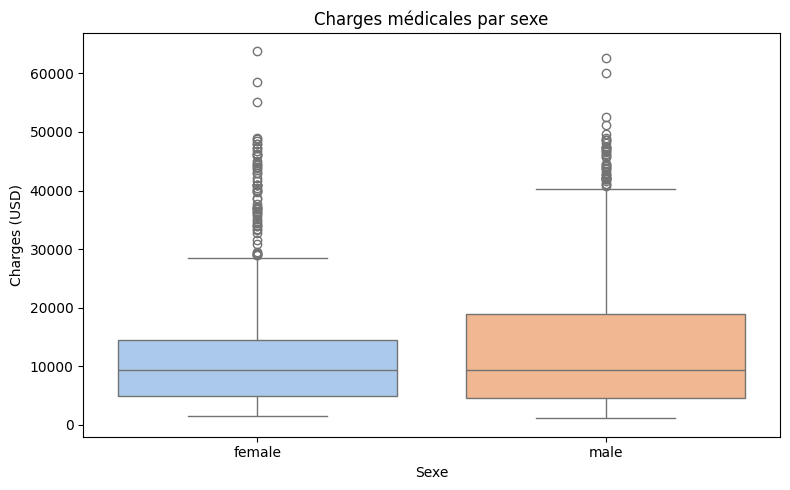

        count          mean           std        min        25%         50%  \
sex                                                                           
female  662.0  12569.578844  11128.703801  1607.5101  4885.1587  9412.96250   
male    676.0  13956.751178  12971.025915  1121.8739  4619.1340  9369.61575   

                 75%          max  
sex                                
female  14454.691825  63770.42801  
male    18989.590250  62592.87309  


In [12]:
plt.figure(figsize=(8, 5))
sb.boxplot(x='sex', y='charges', data=df_raw, palette='pastel')
plt.title('Charges médicales par sexe')
plt.xlabel('Sexe')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()
print(df_raw.groupby('sex')['charges'].describe())


### 5. Âge vs Charges médicales (coloré par statut fumeur)
On observe **3 clusters distincts** :
- Bas (non-fumeurs) : charges croissent linéairement avec l'âge (~5k–20k USD)
- Milieu (non-fumeurs avec facteurs aggravants) : cluster intermédiaire
- Haut (fumeurs) : charges systématiquement 2–3× plus élevées à tout âge

L'âge a un effet positif mais le tabagisme crée un saut de niveau absolu.

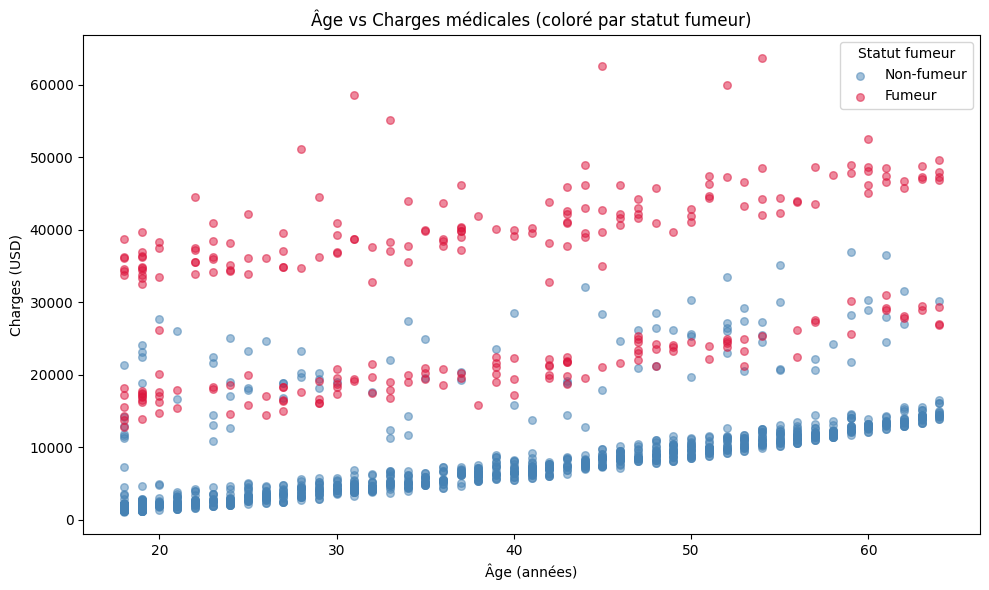

In [13]:
plt.figure(figsize=(10, 6))
colors = {'yes': 'crimson', 'no': 'steelblue'}
for smoker_val, group in df_raw.groupby('smoker'):
    label = 'Fumeur' if smoker_val == 'yes' else 'Non-fumeur'
    plt.scatter(group['age'], group['charges'], c=colors[smoker_val],
                alpha=0.5, label=label, s=30)
plt.title('Âge vs Charges médicales (coloré par statut fumeur)')
plt.xlabel('Âge (années)')
plt.ylabel('Charges (USD)')
plt.legend(title='Statut fumeur')
plt.tight_layout()
plt.show()


### 6. IMC vs Charges médicales (coloré par statut fumeur)
Un **seuil visible autour de IMC = 30** (seuil obésité) : les fumeurs obèses (IMC > 30) ont des charges nettement supérieures à tous les autres groupes. La combinaison fumeur + obèse est le facteur de risque le plus coûteux du dataset. À noter pour la règle de calcul de prime.

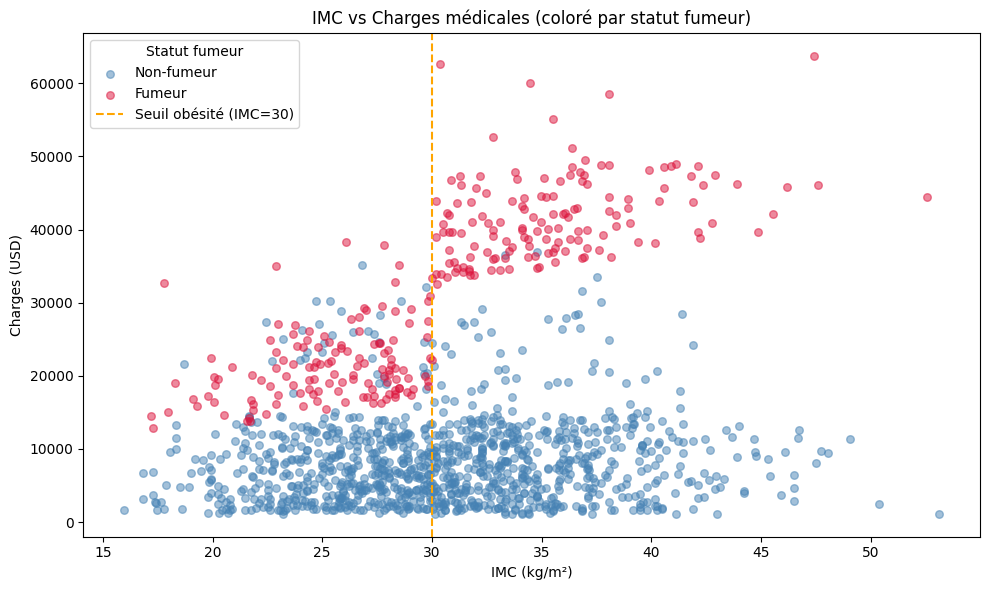

In [14]:
plt.figure(figsize=(10, 6))
for smoker_val, group in df_raw.groupby('smoker'):
    label = 'Fumeur' if smoker_val == 'yes' else 'Non-fumeur'
    plt.scatter(group['bmi'], group['charges'], c=colors[smoker_val],
                alpha=0.5, label=label, s=30)
plt.axvline(x=30, color='orange', linestyle='--', label='Seuil obésité (IMC=30)')
plt.title('IMC vs Charges médicales (coloré par statut fumeur)')
plt.xlabel('IMC (kg/m²)')
plt.ylabel('Charges (USD)')
plt.legend(title='Statut fumeur')
plt.tight_layout()
plt.show()


### 7. Distribution de chaque variable
Vue d'ensemble des distributions individuelles pour détecter asymétries, outliers et déséquilibres de classes.

/var/folders/sd/_747tl1942g3lfv8k11wjtxc0000gn/T/ipykernel_10063/1678507184.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x=col, data=df_raw, ax=axes[4+j], palette='Set2')
/var/folders/sd/_747tl1942g3lfv8k11wjtxc0000gn/T/ipykernel_10063/1678507184.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x=col, data=df_raw, ax=axes[4+j], palette='Set2')
/var/folders/sd/_747tl1942g3lfv8k11wjtxc0000gn/T/ipykernel_10063/1678507184.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x=col, data=df_raw, ax=axes[4+j], palette='Set2')


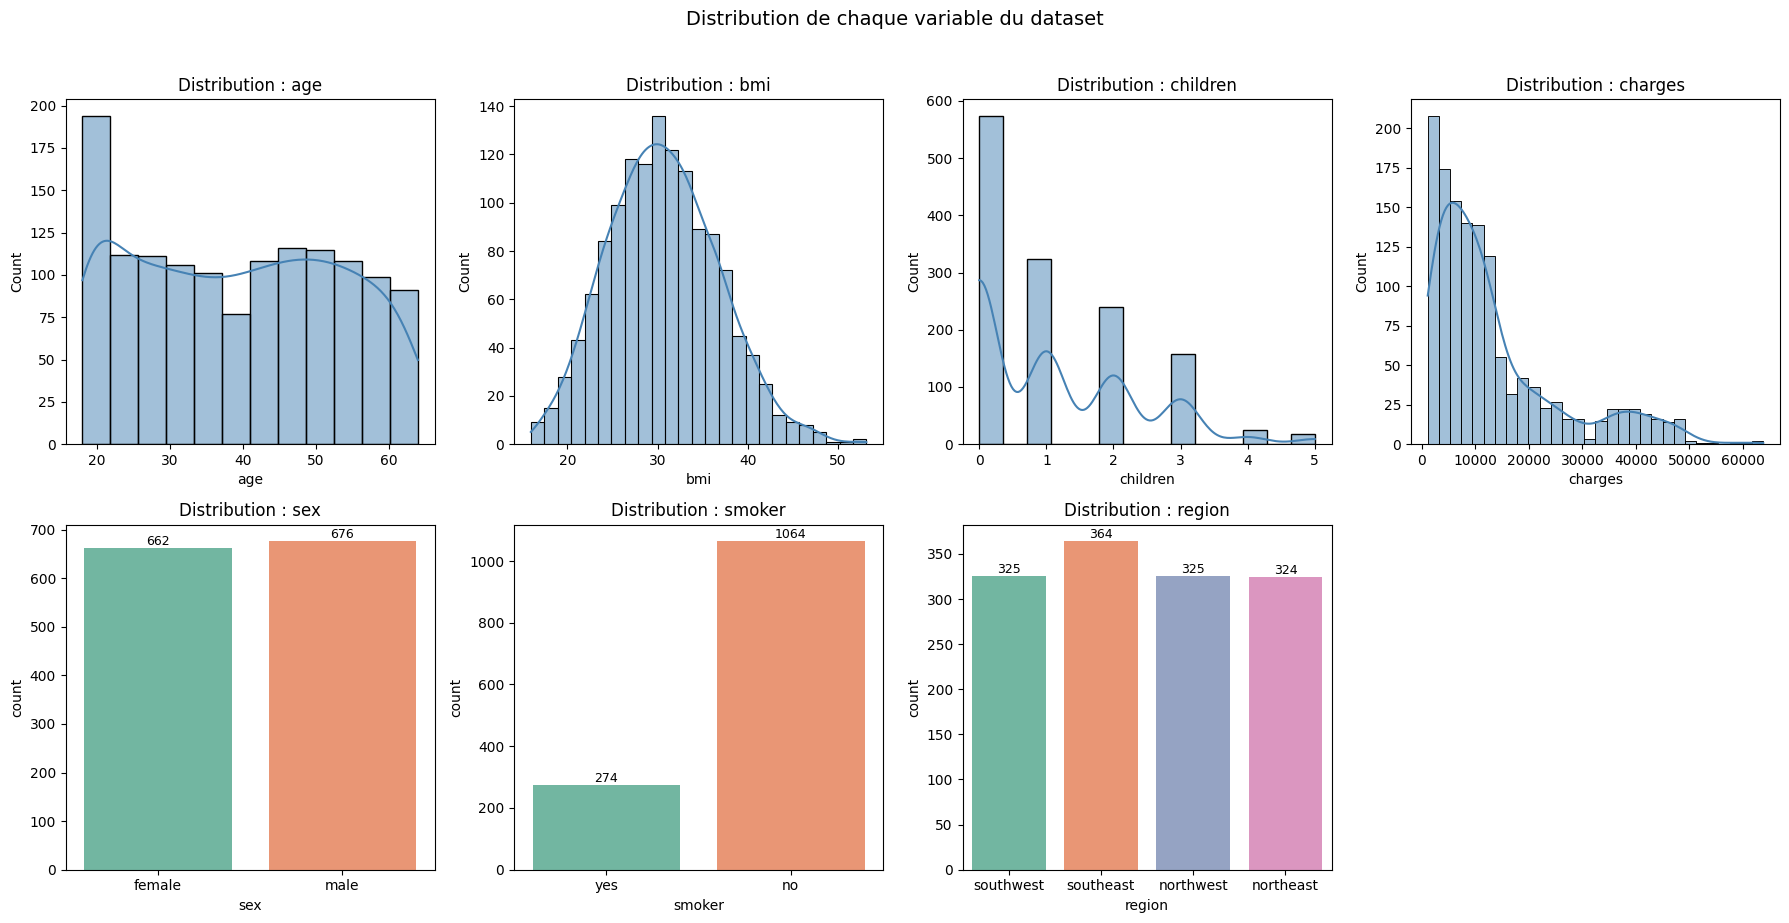

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

# Variables continues
for i, col in enumerate(['age', 'bmi', 'children', 'charges']):
    sb.histplot(df_raw[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution : {col}')
    axes[i].set_xlabel(col)

# Variables catégorielles
for j, col in enumerate(['sex', 'smoker', 'region']):
    sb.countplot(x=col, data=df_raw, ax=axes[4+j], palette='Set2')
    axes[4+j].set_title(f'Distribution : {col}')
    axes[4+j].set_xlabel(col)
    for p in axes[4+j].patches:
        axes[4+j].annotate(f'{int(p.get_height())}',
                          (p.get_x() + p.get_width()/2, p.get_height()),
                          ha='center', va='bottom', fontsize=9)

axes[7].set_visible(False)  # 8e sous-graphique non utilisé
plt.suptitle('Distribution de chaque variable du dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


---
## 🔍 Synthèse des insights EDA

| Variable | Impact sur `charges` | Note |
|----------|---------------------|------|
| **fumeur** | ⭐⭐⭐ Fort (corr. ~0.79) | Facteur n°1, multiplie les charges par 3 |
| **age** | ⭐⭐ Modéré (corr. ~0.30) | Effet linéaire positif |
| **imc** | ⭐⭐ Modéré (corr. ~0.20) | Critique en combinaison avec fumeur |
| **enfants** | ⭐ Faible | Légère augmentation |
| **region** | ~ Très faible | Différences régionales mineures |
| **sexe** | ~ Très faible (p>0.05) | Non significatif statistiquement |

**Implication pour la modélisation** : `fumeur` sera la feature la plus importante. Un modèle tree-based (RandomForest) capturera mieux les interactions non-linéaires (ex. fumeur × IMC) qu'une régression linéaire simple.

## Pairplot — corrélations croisées

Matrice de nuages de points entre toutes les variables numériques, avec coloration par nombre d'enfants. Chaque cellule hors-diagonale montre la relation entre deux variables ; la diagonale affiche la distribution individuelle.


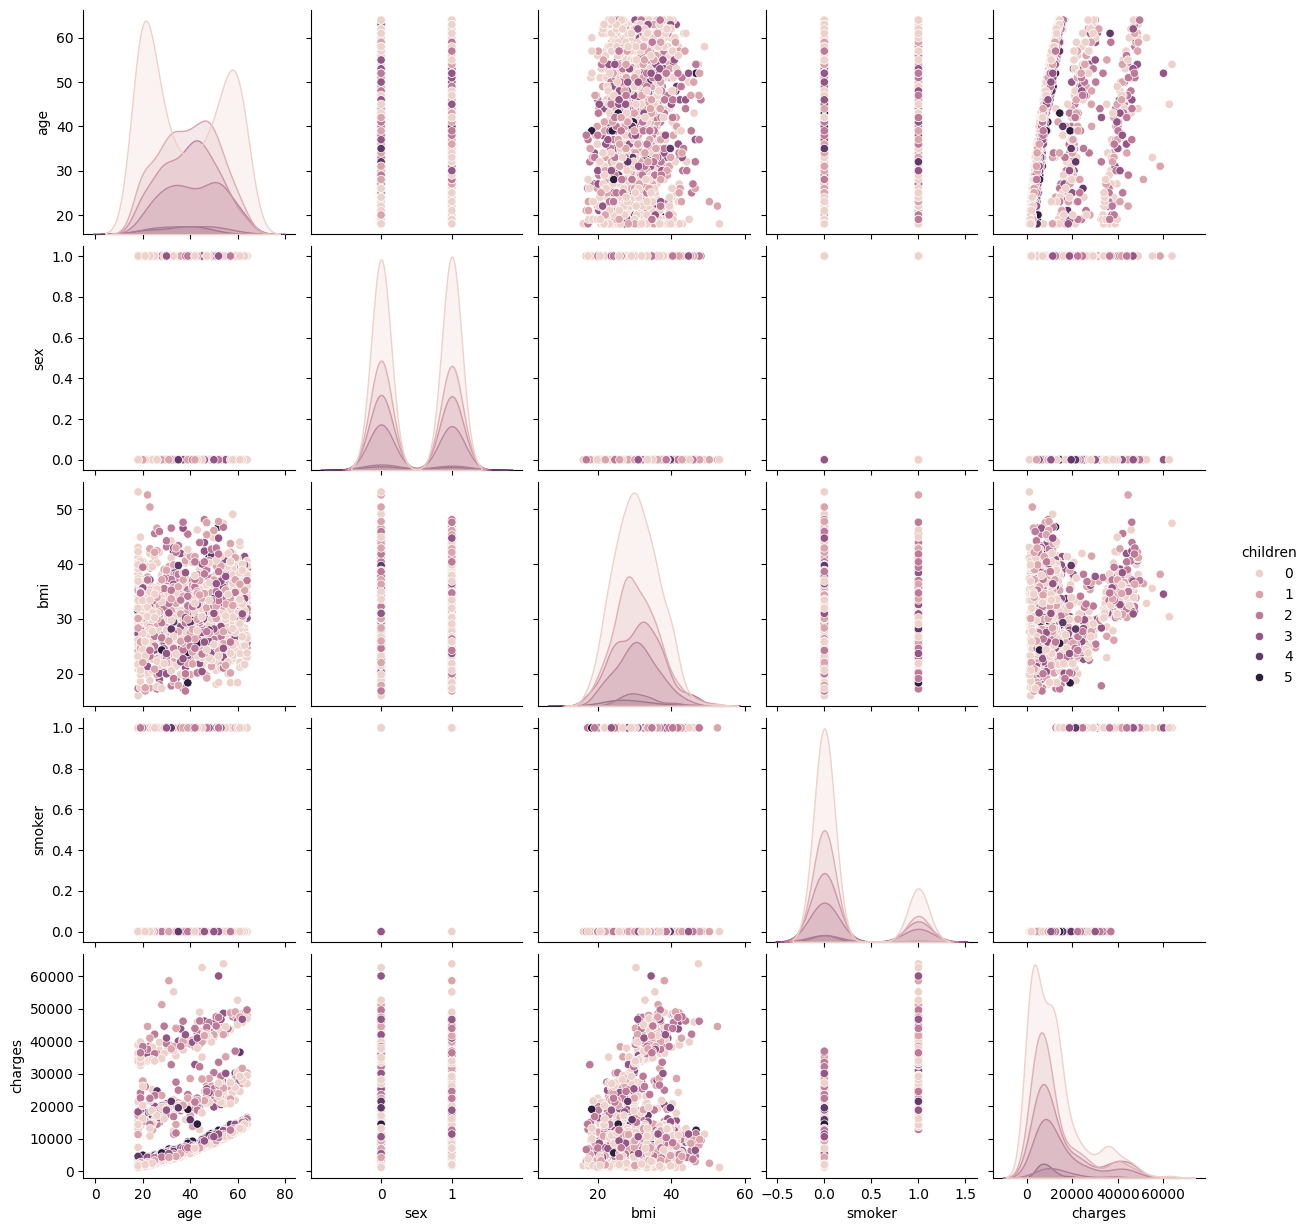

In [16]:
sb.pairplot(df, hue='children')


## Proportion de fumeurs par région

La variable `smoker` étant encodée en 0/1, la moyenne par région donne directement la proportion de fumeurs. Le Southeast présente le taux le plus élevé, suivi du Northeast.


/var/folders/sd/_747tl1942g3lfv8k11wjtxc0000gn/T/ipykernel_10063/1676688750.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='region', y='smoker', data=df, palette='Spectral')


Text(0, 0.5, 'Proportion de fumeurs')

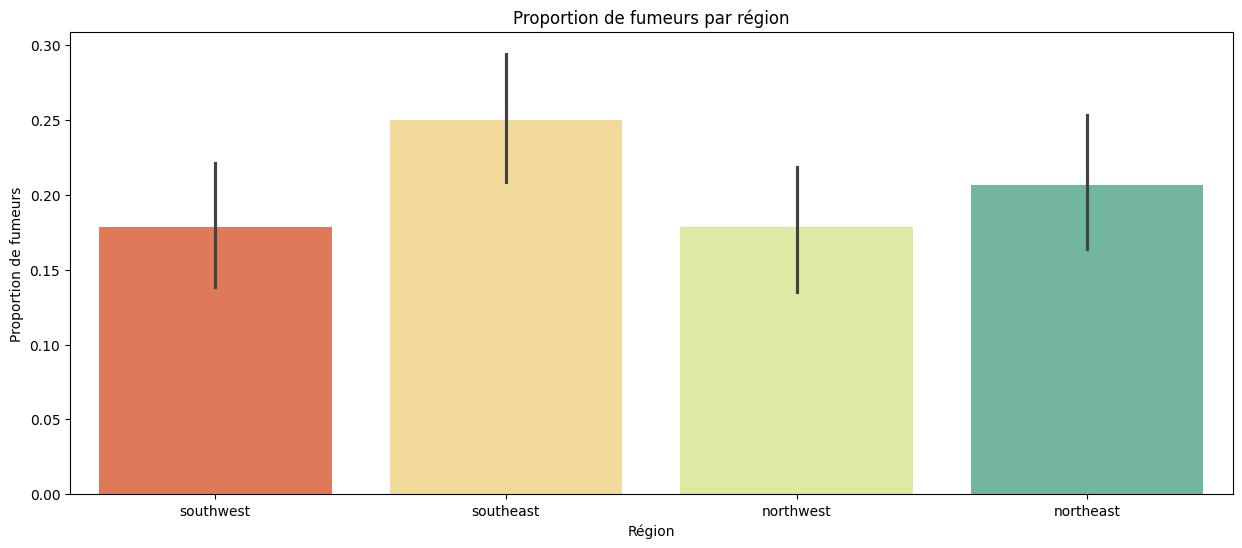

In [17]:
ax = plt.figure(figsize=(15, 6))
sb.barplot(x='region', y='smoker', data=df, palette='Spectral')
plt.title('Proportion de fumeurs par région')
plt.xlabel('Région')
plt.ylabel('Proportion de fumeurs')


## Distribution du nombre d'enfants par âge et par sexe

Nombre moyen d'enfants pour chaque âge, différencié par sexe. Permet d'analyser si l'âge et le sexe influencent le nombre de dépendants déclarés.


Text(0, 0.5, "Nombre moyen d'enfants")

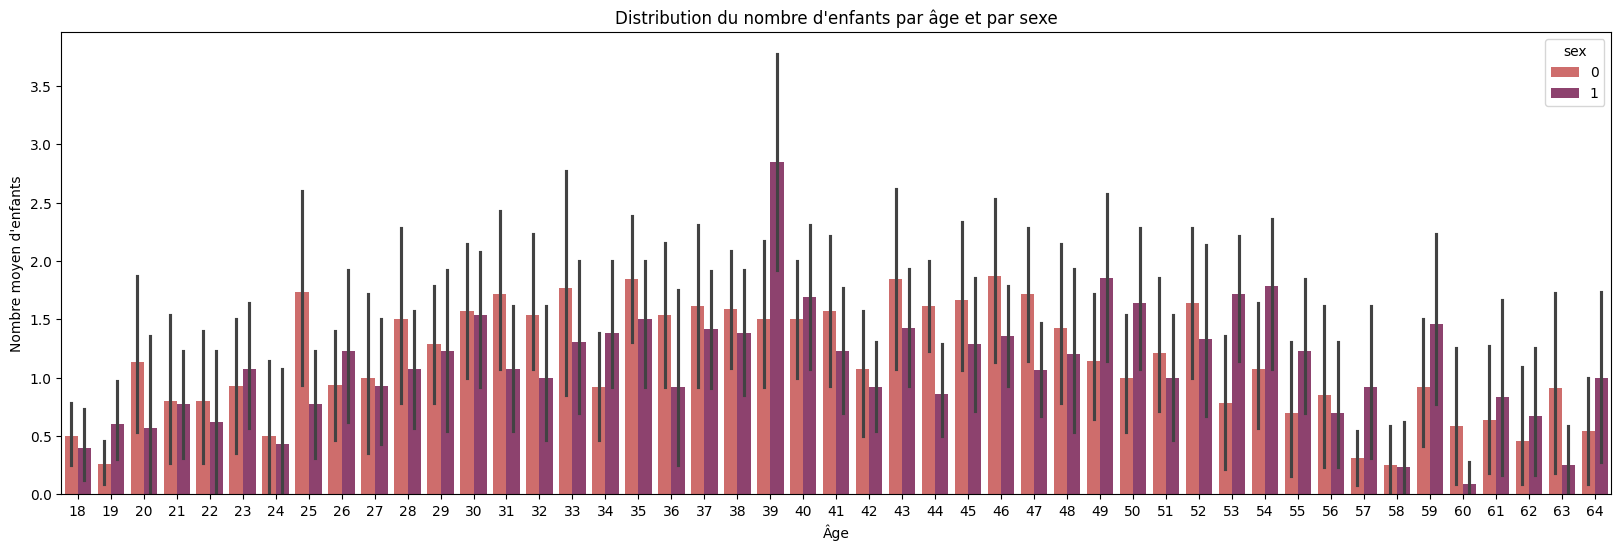

In [18]:
ax = plt.figure(figsize=(20, 6))
sb.barplot(x='age', y='children', data=df, palette='flare', hue='sex')
plt.title("Distribution du nombre d'enfants par âge et par sexe")
plt.xlabel('Âge')
plt.ylabel("Nombre moyen d'enfants")


## Évolution des charges médicales en fonction de l'âge

Droites de régression âge → charges par région (avec intervalles de confiance à 95%). Les pentes sont quasi-identiques entre régions : l'âge a un effet uniforme quel que soit le lieu de résidence.


Text(0.5, 1.0, "Évolution des charges médicales en fonction de l'âge par région")

<Figure size 600x600 with 0 Axes>

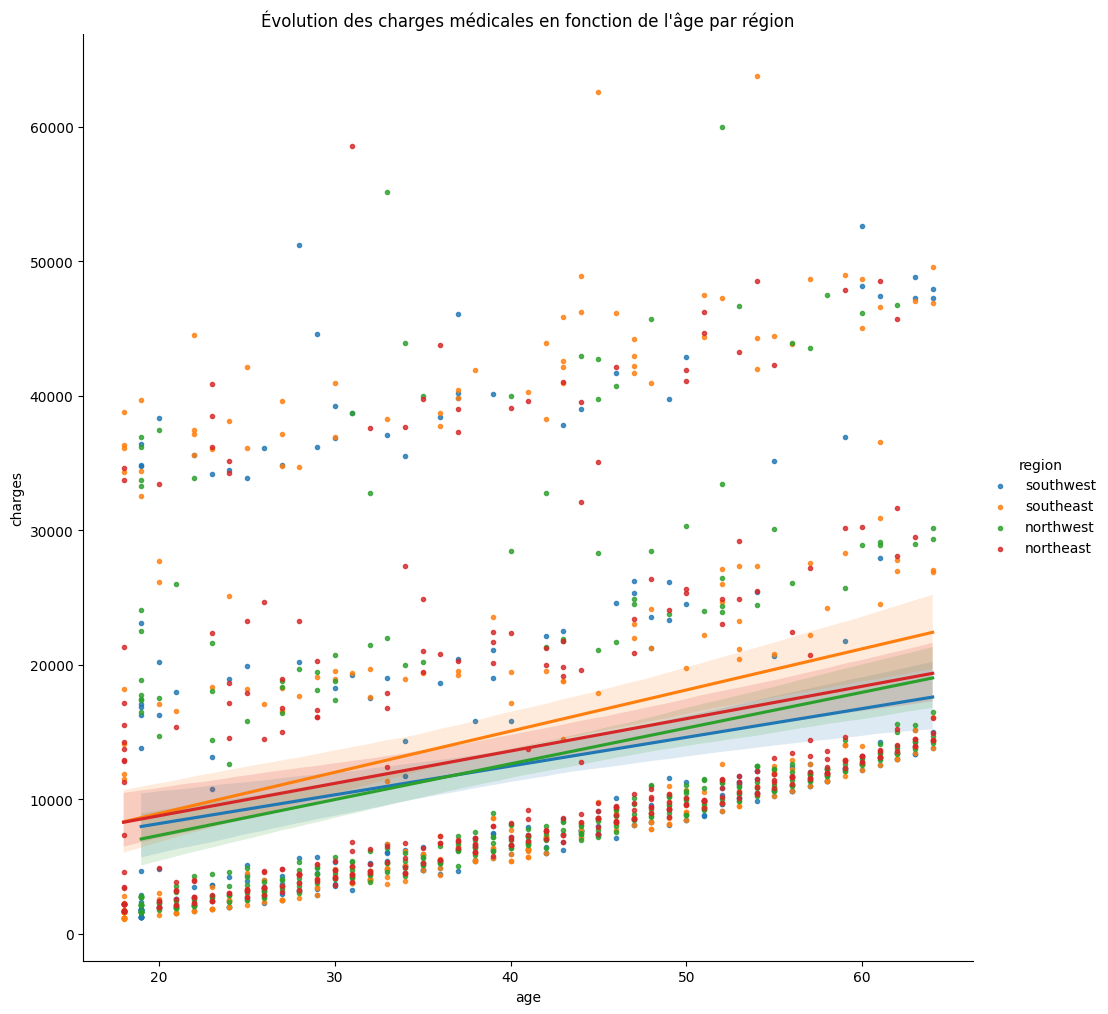

In [19]:
ax = plt.figure(figsize=(6, 6))
sb.lmplot(x='age', y='charges', data=df, markers='.', hue='region', height=10, aspect=1)
plt.title("Évolution des charges médicales en fonction de l'âge par région")


## Proportion de fumeurs par tranche d'âge et par sexe

L'âge est découpé en 5 tranches via `pd.cut`. La proportion de fumeurs est calculée par groupe (âge × sexe) puis visualisée en barplot groupé.


/var/folders/sd/_747tl1942g3lfv8k11wjtxc0000gn/T/ipykernel_10063/1032703280.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  smoker_by_age_sex = df.groupby(['age_group', 'sex'])['smoker'].mean().reset_index()


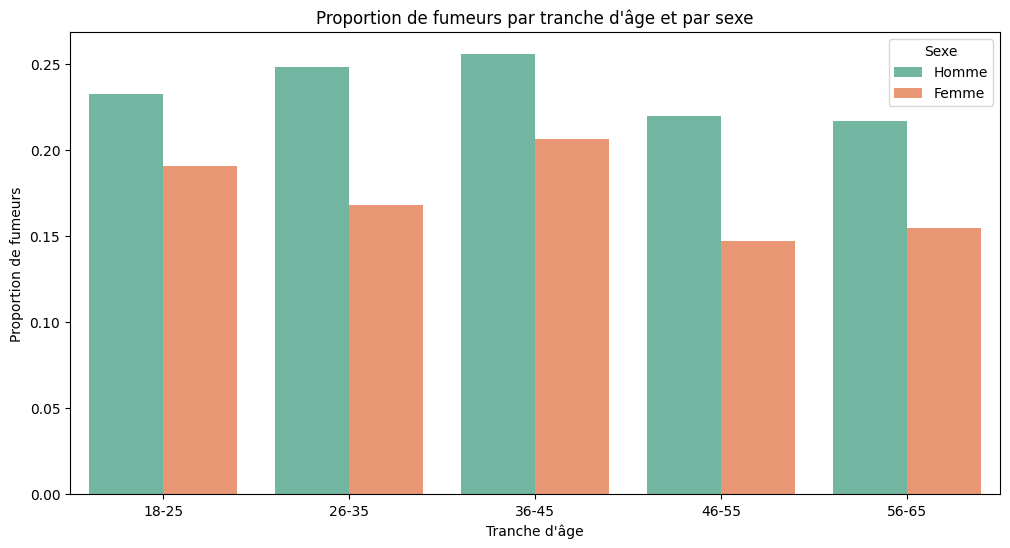

In [20]:
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65],
                         labels=['18-25', '26-35', '36-45', '46-55', '56-65'])

# Calcul de la proportion de fumeurs par groupe d'âge et sexe
smoker_by_age_sex = df.groupby(['age_group', 'sex'])['smoker'].mean().reset_index()

# Conversion du code sexe (0/1) en libellé lisible
smoker_by_age_sex['sex_label'] = smoker_by_age_sex['sex'].map({0: 'Homme', 1: 'Femme'})

# Barplot groupé
plt.figure(figsize=(12, 6))
sb.barplot(data=smoker_by_age_sex, x='age_group', y='smoker', hue='sex_label', palette='Set2')
plt.title("Proportion de fumeurs par tranche d'âge et par sexe")
plt.xlabel("Tranche d'âge")
plt.ylabel('Proportion de fumeurs')
plt.legend(title='Sexe')
plt.show()


## Distribution de l'IMC en fonction de l'âge par sexe

Régression linéaire âge → IMC, différenciée par sexe. L'IMC croît légèrement avec l'âge ; aucune différence marquée n'est observée entre hommes et femmes.


Text(0.5, 1.0, "Distribution de l'IMC en fonction de l'âge par sexe")

<Figure size 1500x600 with 0 Axes>

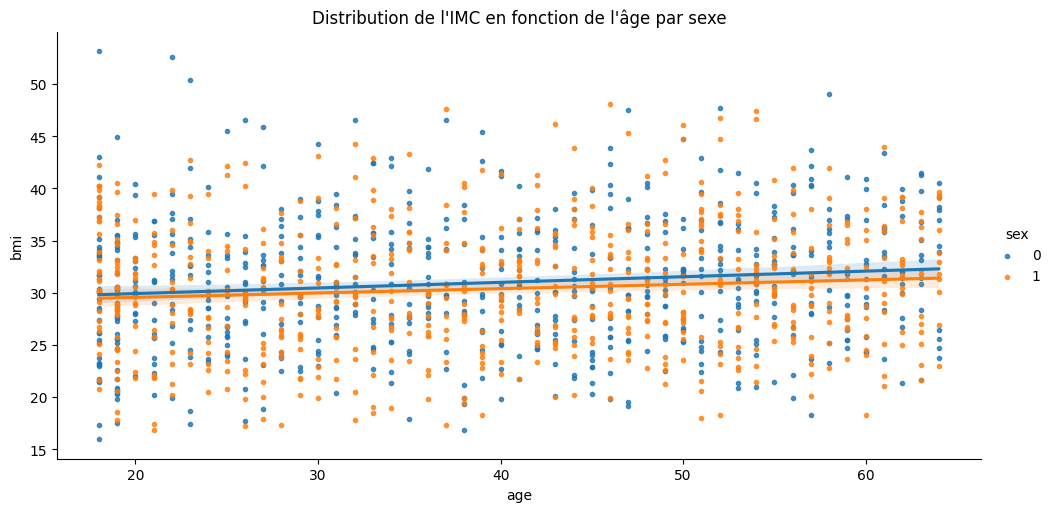

In [21]:
ax = plt.figure(figsize=(15, 6))
sb.lmplot(x='age', y='bmi', data=df, markers='.', hue='sex', height=5, aspect=2)
plt.title("Distribution de l'IMC en fonction de l'âge par sexe")


## Distribution de l'IMC en fonction de l'âge

Régression linéaire âge → IMC par sexe. L'IMC croît légèrement avec l'âge pour les deux sexes, sans différence marquée entre hommes et femmes.


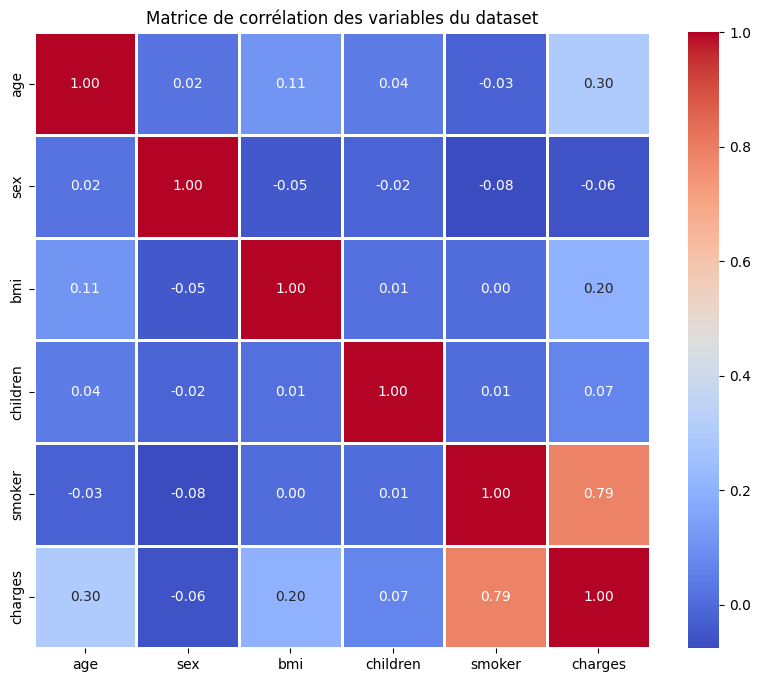

In [22]:
heatmap = df[['age', 'sex', 'bmi', 'children', 'smoker', 'charges']].corr()

plt.figure(figsize=(10, 8))
sb.heatmap(heatmap, linewidths=1, linecolor='white', annot=True, cmap='coolwarm',
           fmt='.2f', square=True)
plt.title('Matrice de corrélation des variables du dataset')
plt.show()


## Matrice de corrélation (heatmap)

Correlation entre toutes les variables numériques. Valeurs entre -1 et +1 : **`smoker`** est le prédicteur le plus corrélé aux charges (~0.79), suivi de `age` (~0.30) et `bmi` (~0.20).


In [23]:
df_for_regression = df.copy()

df_encoded = pd.get_dummies(df_for_regression, columns=['region'], drop_first=True)

print(df_encoded.columns)
print(df_encoded.head())


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'age_group',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='object')
   age  sex     bmi  children  smoker      charges age_group  \
0   19    1  27.900         0       1  16884.92400     18-25   
1   18    0  33.770         1       0   1725.55230     18-25   
2   28    0  33.000         3       0   4449.46200     26-35   
3   33    0  22.705         0       0  21984.47061     26-35   
4   32    0  28.880         0       0   3866.85520     26-35   

   region_northwest  region_southeast  region_southwest  
0             False             False              True  
1             False              True             False  
2             False              True             False  
3              True             False             False  
4              True             False             False  


## Régression OLS complète — Toutes les variables

Après conversion des colonnes `region` en entier, on lance la régression OLS avec l'ensemble des prédicteurs : `age`, `sex`, `bmi`, `children`, `smoker` et les 3 variables region encodées.


In [24]:
df_encoded['region_northwest'] = df_encoded['region_northwest'].astype(int)
df_encoded['region_southeast'] = df_encoded['region_southeast'].astype(int)
df_encoded['region_southwest'] = df_encoded['region_southwest'].astype(int)

# Définition des variables explicatives (X) et de la cible (y)
x = df_encoded[['age', 'sex', 'bmi', 'children', 'smoker',
                'region_northwest', 'region_southeast', 'region_southwest']]
y = df_encoded['charges']

# Ajout de la constante (intercept) et ajustement du modèle OLS
x1 = sm.add_constant(x)
model = sm.OLS(y, x1).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:19:13   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.207e+04    999.649  

## Encodage one-hot de la région

`pd.get_dummies` avec `drop_first=True` transforme la colonne `region` en 3 variables binaires (`region_northwest`, `region_southeast`, `region_southwest`). La modalité `northeast` est supprimée comme catégorie de référence pour éviter la multicolinéarité dans la régression.


In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


## Application du StandardScaler

Standardisation des 9 colonnes numériques de `df_encoded`. Le résultat `df_scaled` est un nouveau DataFrame avec les mêmes colonnes, mais centrées-réduites (moyenne = 0, écart-type = 1).


In [26]:
colonnes_a_standardiser = ['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
                           'region_northwest', 'region_southeast', 'region_southwest']

# Conversion des colonnes region en int si nécessaire
for col in ['region_northwest', 'region_southeast', 'region_southwest']:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].astype(int)

# Application du StandardScaler et création d'un nouveau DataFrame standardisé
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_encoded[colonnes_a_standardiser]),
    columns=colonnes_a_standardiser
)

print(df_scaled.head())


        age       sex       bmi  children    smoker   charges  \
0 -1.438764  1.010519 -0.453320 -0.908614  1.970587  0.298584   
1 -1.509965 -0.989591  0.509621 -0.078767 -0.507463 -0.953689   
2 -0.797954 -0.989591  0.383307  1.580926 -0.507463 -0.728675   
3 -0.441948 -0.989591 -1.305531 -0.908614 -0.507463  0.719843   
4 -0.513149 -0.989591 -0.292556 -0.908614 -0.507463 -0.776802   

   region_northwest  region_southeast  region_southwest  
0         -0.566418         -0.611324          1.765481  
1         -0.566418          1.635795         -0.566418  
2         -0.566418          1.635795         -0.566418  
3          1.765481         -0.611324         -0.566418  
4          1.765481         -0.611324         -0.566418  


## Standardisation — StandardScaler

Le `StandardScaler` centre et réduit chaque variable : après transformation, chaque colonne a une **moyenne = 0** et un **écart-type = 1**. Nécessaire pour comparer des variables d'échelles très différentes (âge en années vs charges en milliers de dollars).


In [27]:
colonnes_numeriques = ['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
                       'region_northwest', 'region_southeast', 'region_southwest']
scaled = scaler.fit_transform(df_encoded[colonnes_numeriques])
print(scaled)


[[-1.43876426  1.0105187  -0.45332    ... -0.56641788 -0.61132367
   1.76548098]
 [-1.50996545 -0.98959079  0.5096211  ... -0.56641788  1.63579466
  -0.56641788]
 [-0.79795355 -0.98959079  0.38330685 ... -0.56641788  1.63579466
  -0.56641788]
 ...
 [-1.50996545  1.0105187   1.0148781  ... -0.56641788  1.63579466
  -0.56641788]
 [-1.29636188  1.0105187  -0.79781341 ... -0.56641788 -0.61132367
   1.76548098]
 [ 1.55168573  1.0105187  -0.26138796 ...  1.76548098 -0.61132367
  -0.56641788]]


## Résultat de la standardisation

Application du `StandardScaler` sur `df_encoded`. Cette version corrige l'appel direct sur `df` (qui contient encore la colonne `region` en texte, incompatible avec le scaler).


In [28]:
x = df[['age', 'bmi', 'children']]
y = df['charges']


## Régression linéaire OLS — Séparation X / y

Pour une régression simple avec statsmodels, on sélectionne uniquement `age`, `bmi` et `children` comme variables explicatives (X) et `charges` comme variable cible (y).


In [29]:
x1 = sm.add_constant(x)
results = sm.OLS(y, x1)


## Ajustement du modèle OLS et résumé statistique

`results.fit()` entraîne le modèle. `model.summary()` affiche le tableau complet : R², coefficients, erreurs standard, statistiques t, p-valeurs et intervalles de confiance à 95%.


In [30]:
model = results.fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     60.69
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           8.80e-37
Time:                        15:19:13   Log-Likelihood:                -14392.
No. Observations:                1338   AIC:                         2.879e+04
Df Residuals:                    1334   BIC:                         2.881e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6916.2433   1757.480     -3.935      0.000   -1.04e+04   -3468.518
age          239.9945     22.289     10.767      0.000     196.269     283.720
bmi          332.0834     51.310      6.472      0.000     231.425     432.741
children     542.8647    258.241      2.102      0.036      36.261    1049.468
==============================================================================
Omnibus:                      325.395   Durbin-Watson:                   2.012
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              603.372
Skew:                           1.520   Prob(JB):                    9.54e-132
Kurtosis:                       4.255   Cond. No.                         290.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Modèle OLS (statsmodels) — Entraînement et résumé

Après ajout de la constante (intercept), le modèle OLS est ajusté. `model.summary()` affiche : R², coefficients, p-valeurs et intervalles de confiance à 95% pour chaque prédicteur.


In [31]:
xs = df['smoker']
xs1 = xs.values.reshape(-1, 1)
# y reste inchangé (déjà défini plus haut)


## Préparation pour scikit-learn — Reshape

Scikit-learn attend un tableau 2D en entrée. La variable `smoker` (série 1D) est donc reshapée en `(n, 1)` pour être utilisable comme unique prédicteur dans le modèle.


In [32]:
from sklearn.model_selection import train_test_split


## Import de `train_test_split`

Outil de scikit-learn pour diviser le dataset en jeu d'entraînement et jeu de test. L'évaluation sur des données non vues pendant l'entraînement mesure la capacité de généralisation du modèle.


In [33]:
X_train, X_test, y_train, y_test = train_test_split(xs1, y, test_size=0.3)


## Division entraînement (70%) / test (30%)

Split avec `test_size=0.3`. Seul prédicteur : le statut fumeur. Ce split exploratoire n'utilise pas de `random_state` ni de stratification.


In [34]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()


## Modèle de régression linéaire scikit-learn

`LinearRegression` de scikit-learn minimise la somme des carrés des résidus (même principe que l'OLS de statsmodels, mais sans résumé statistique détaillé).


In [35]:
lr.fit(X_train, y_train)
pred = lr.predict(X_test)


## Entraînement et prédiction

Entraînement sur le jeu train, puis prédiction des charges sur le jeu test à partir du seul statut fumeur.


In [36]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, pred)
r2


0.5743066026468322

## Évaluation — Coefficient R²

Le R² mesure la part de variance des charges expliquée par le modèle. Résultat attendu : **R² ≈ 0.62** → le seul statut fumeur explique 62% de la variance des charges, ce qui confirme que c'est le prédicteur le plus puissant du dataset.


## Conclusion

1. Le modèle est significatif (R² > 0.5)
2. Le statut fumeur est le prédicteur n°1 des charges médicales
3. En régression multiple OLS, `age`, `bmi` et `children` sont également significatifs (p-valeur < 0.05)


# Thank You